In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy

In [14]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined.parquet")
Labled_theses_df = pd.read_csv('wahlomaten_thesen_positionen.csv')

In [15]:
lable_colums_list = Labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [16]:
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These'].tolist()
predicted_theses_df = copy.deepcopy(Labled_theses_df)

In [17]:
parties_list

['SPD', 'CDU / CSU', 'GRÜNE', 'AfD', 'FDP', 'Die Linke']

In [18]:
all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


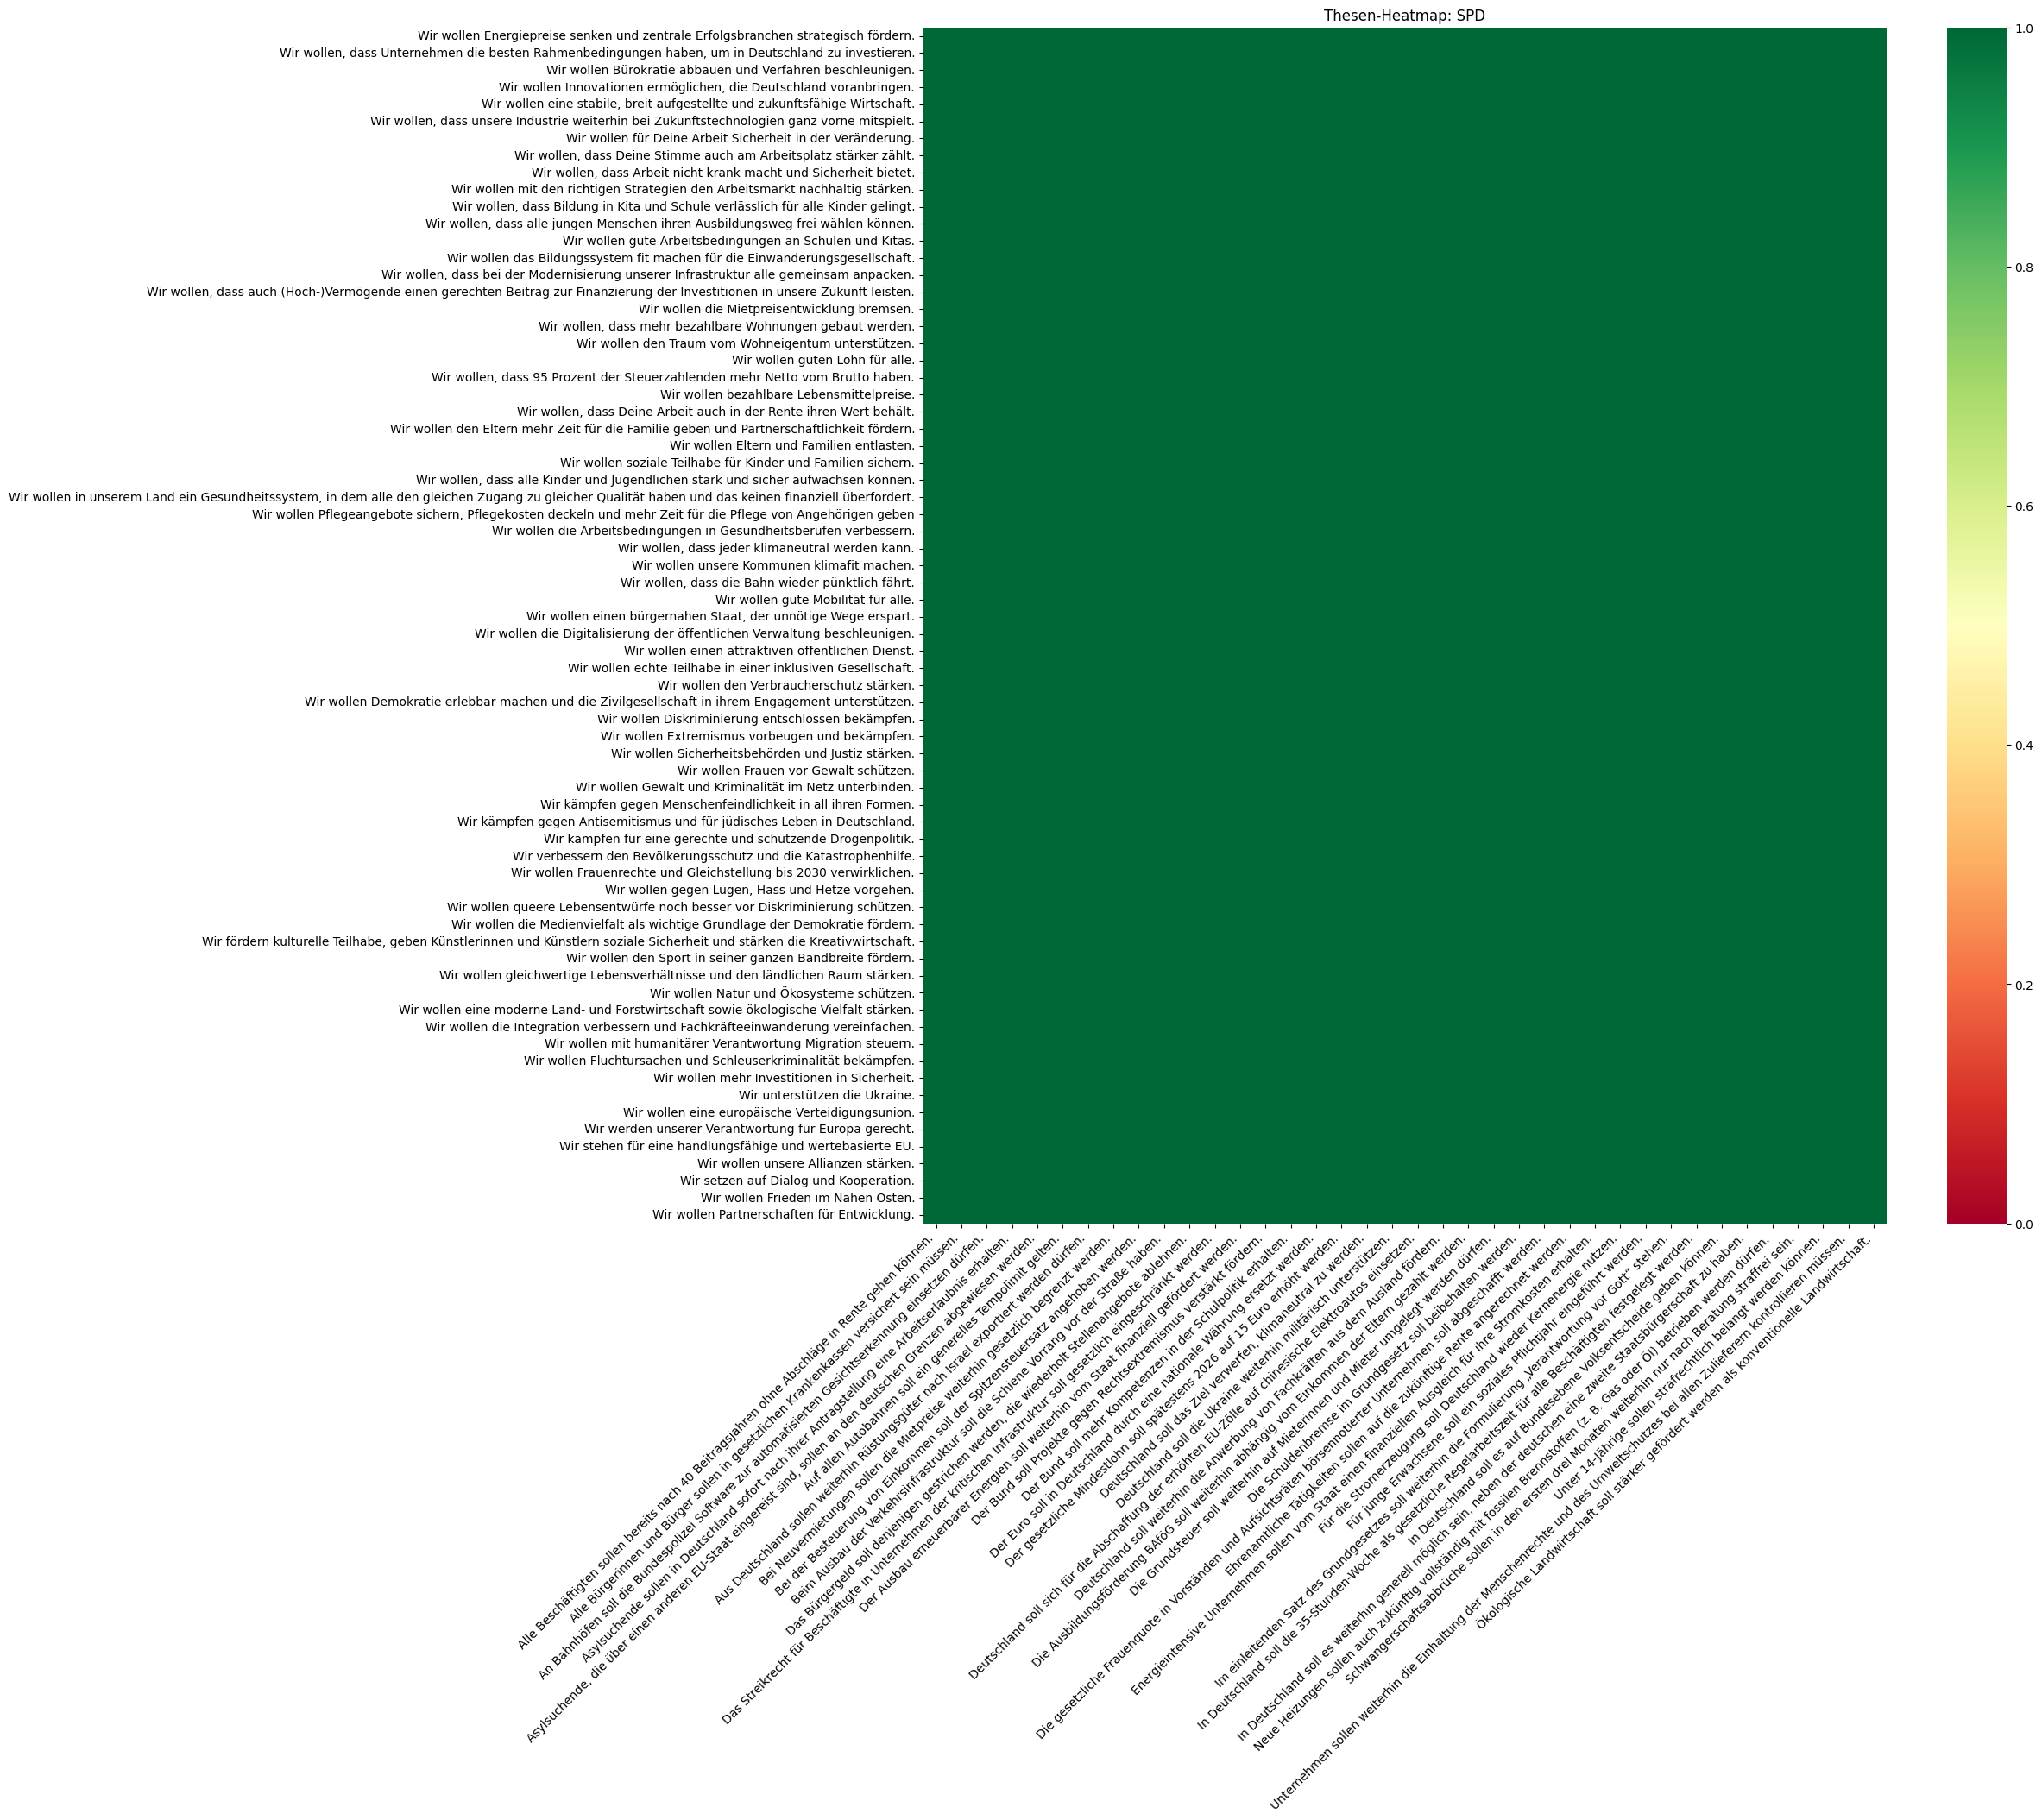

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


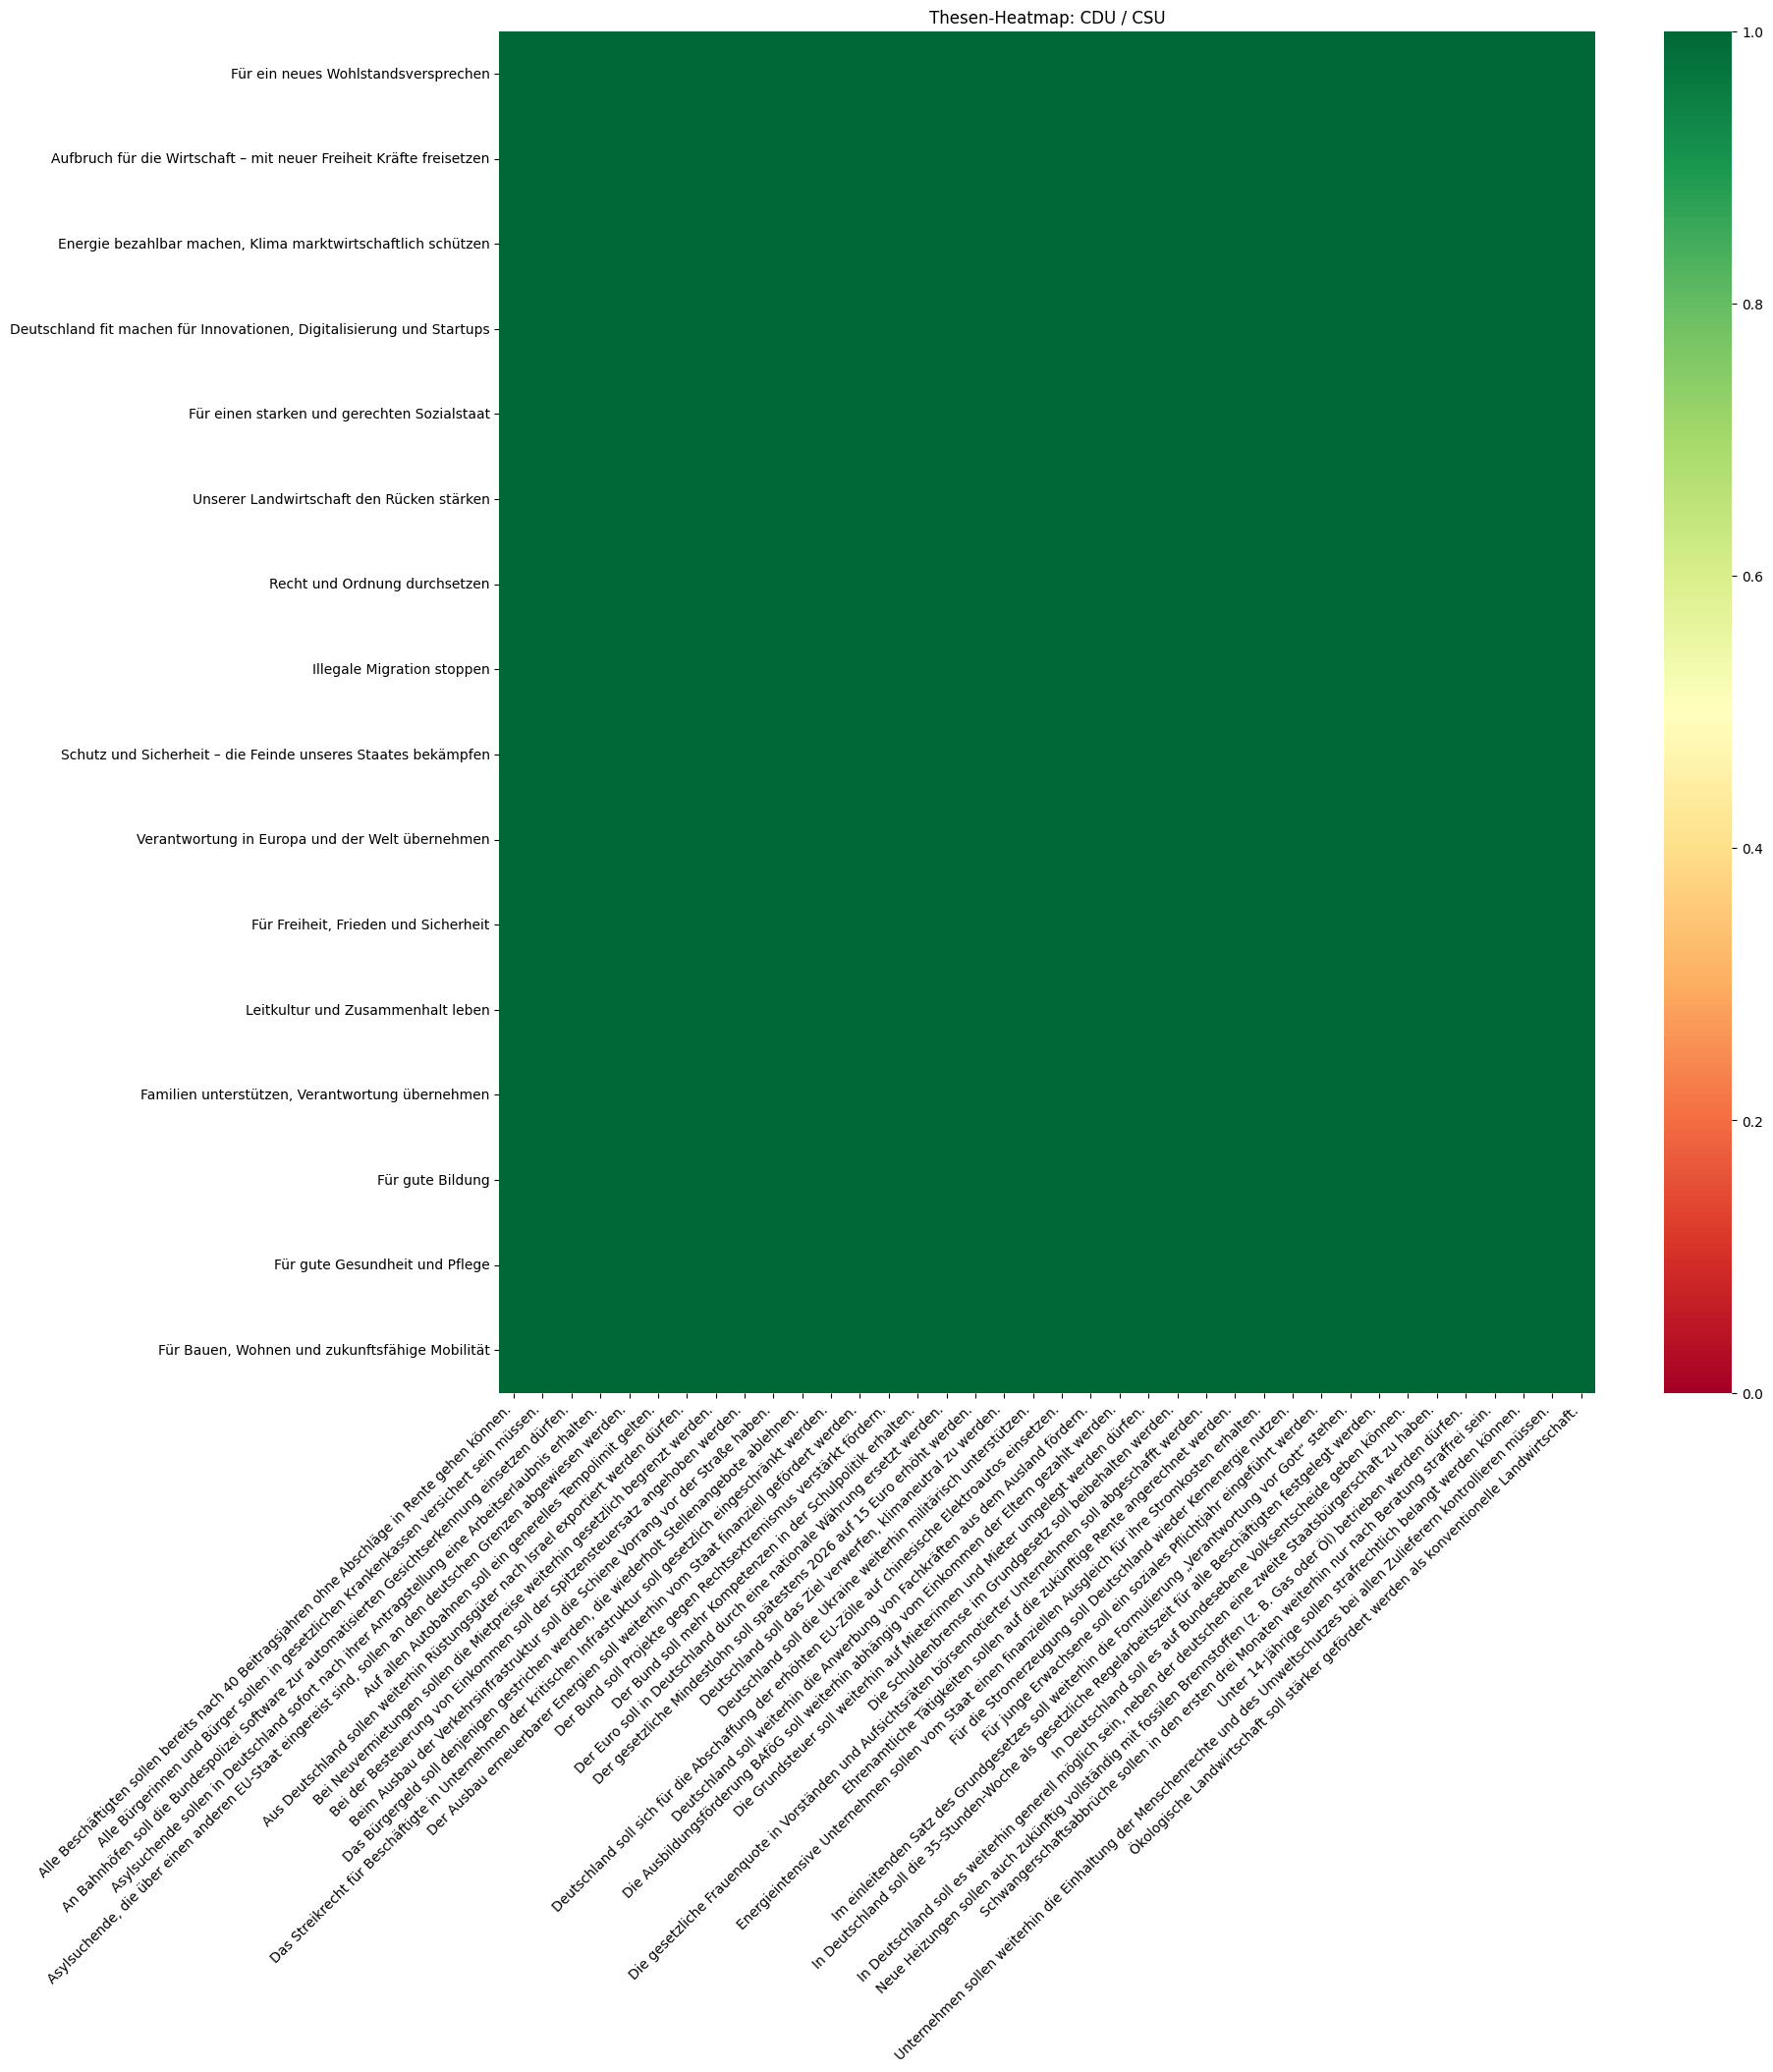

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


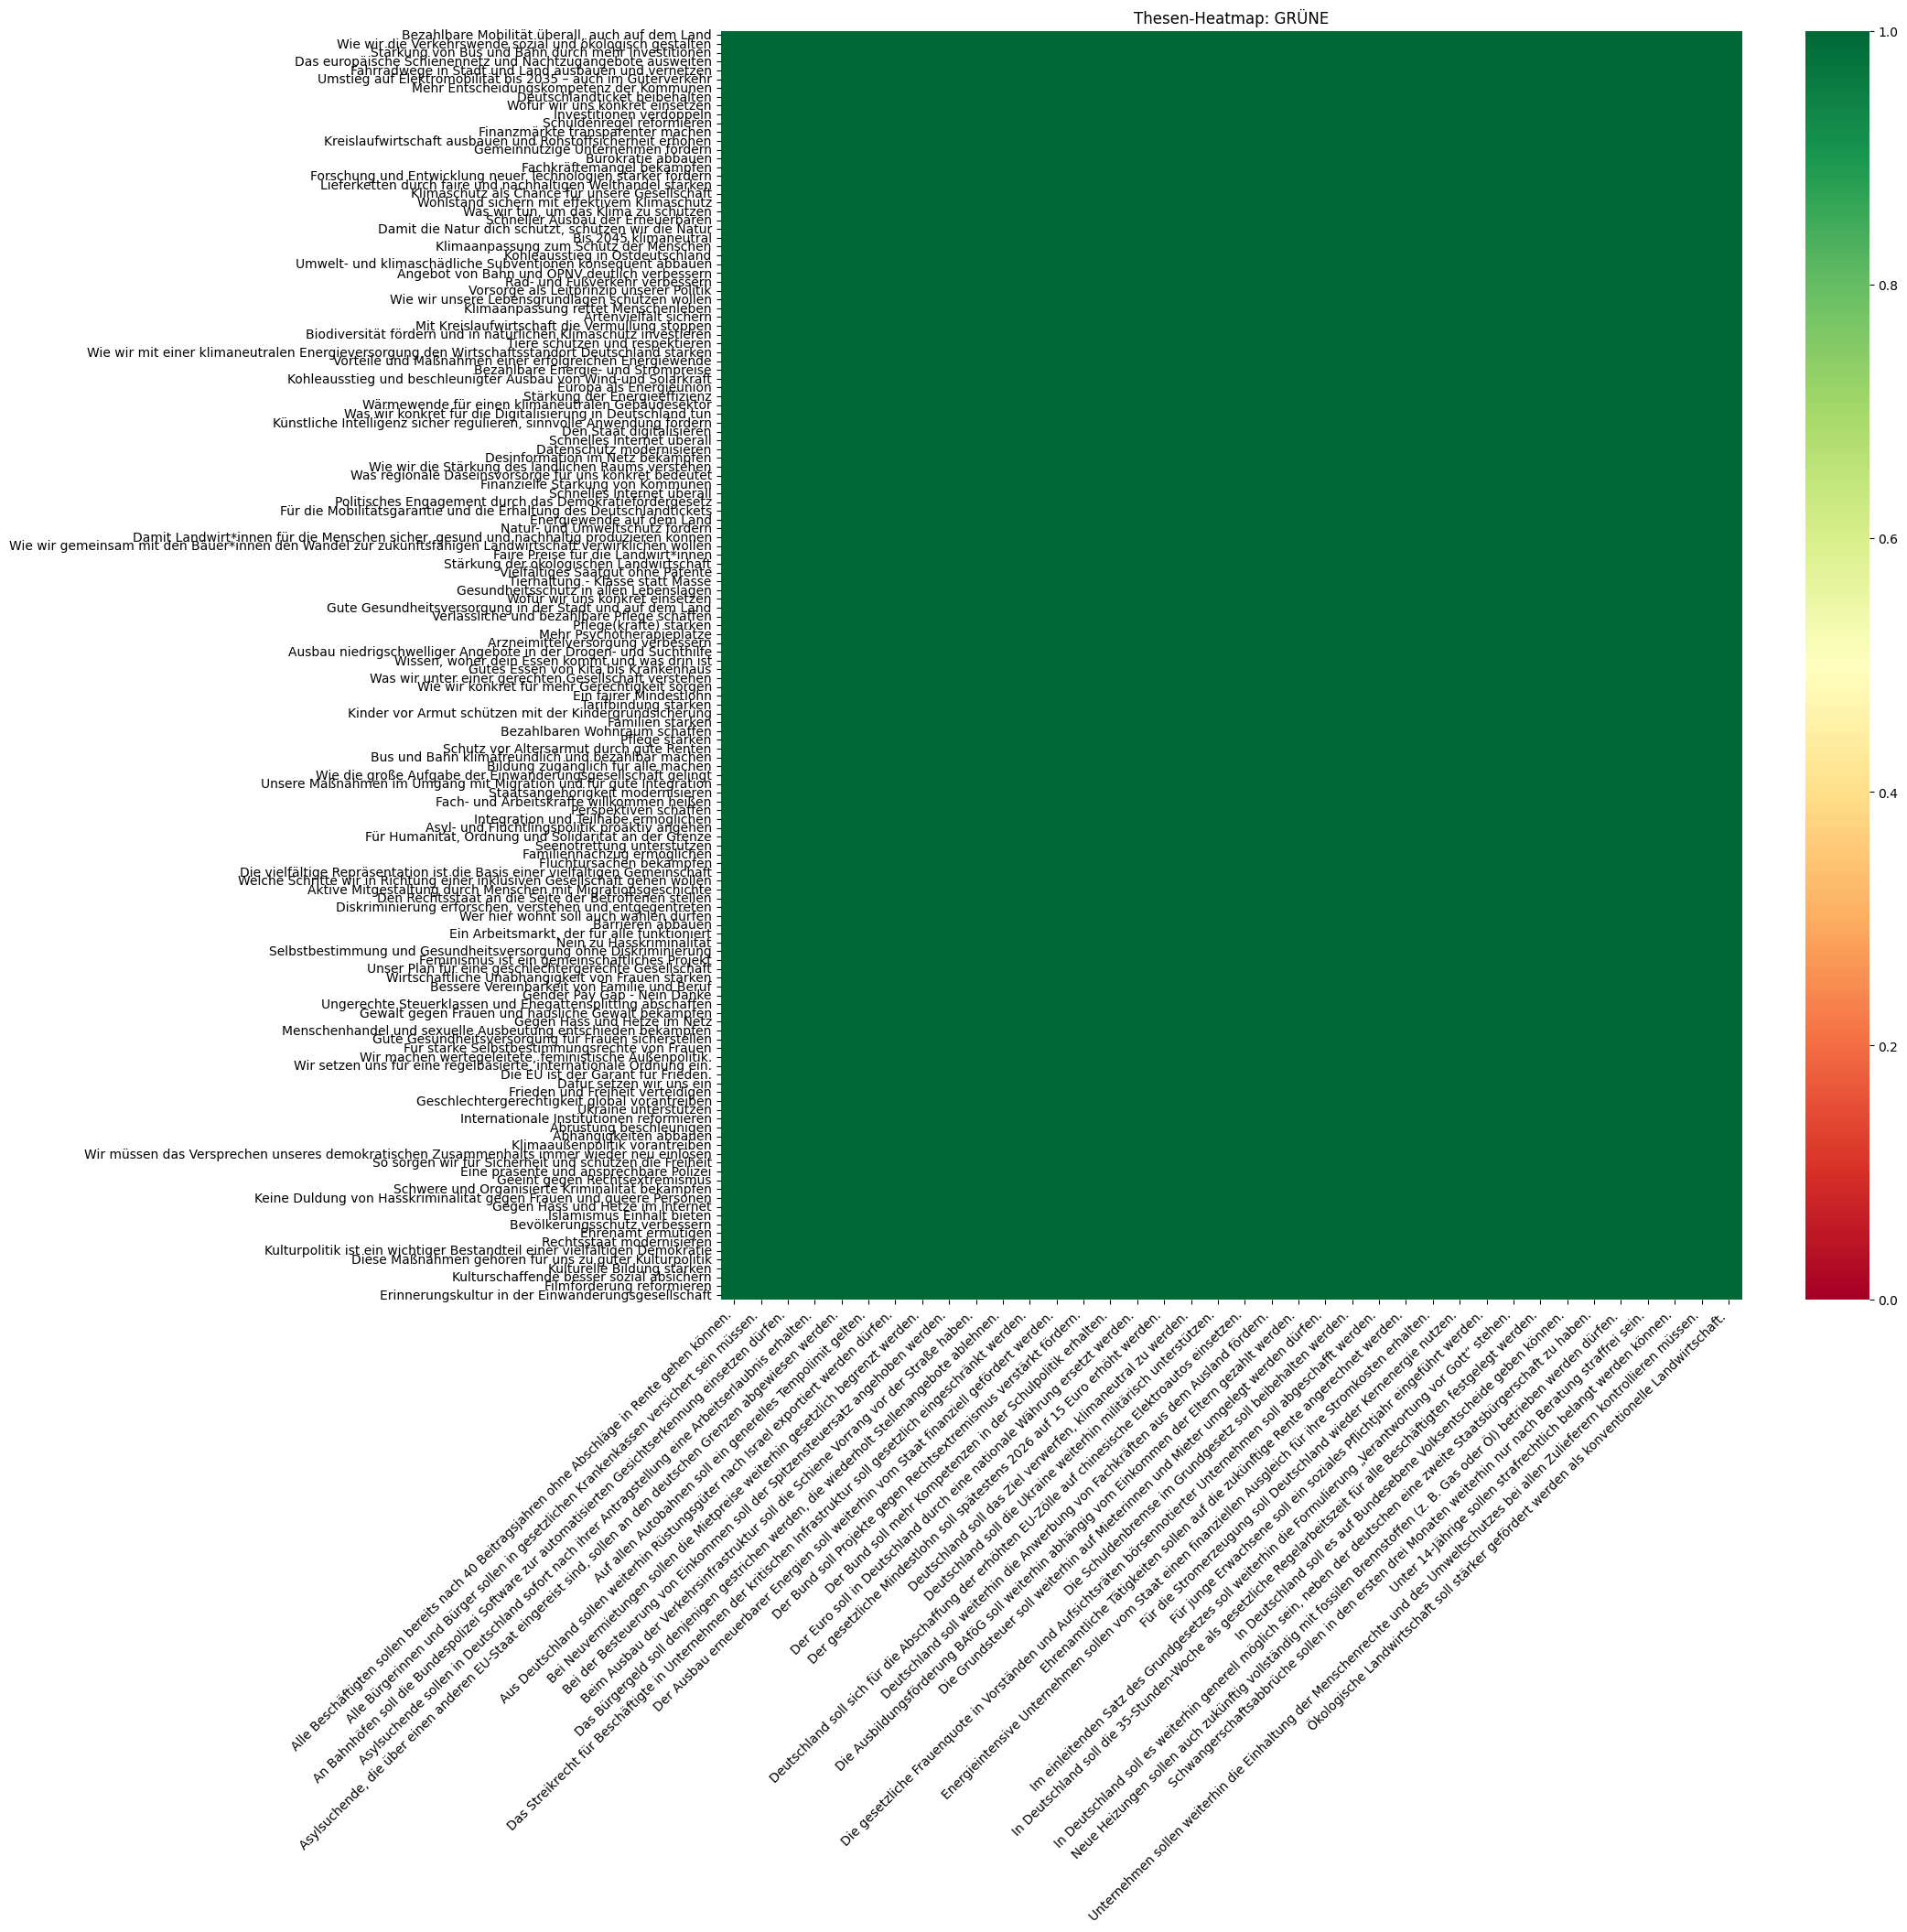

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


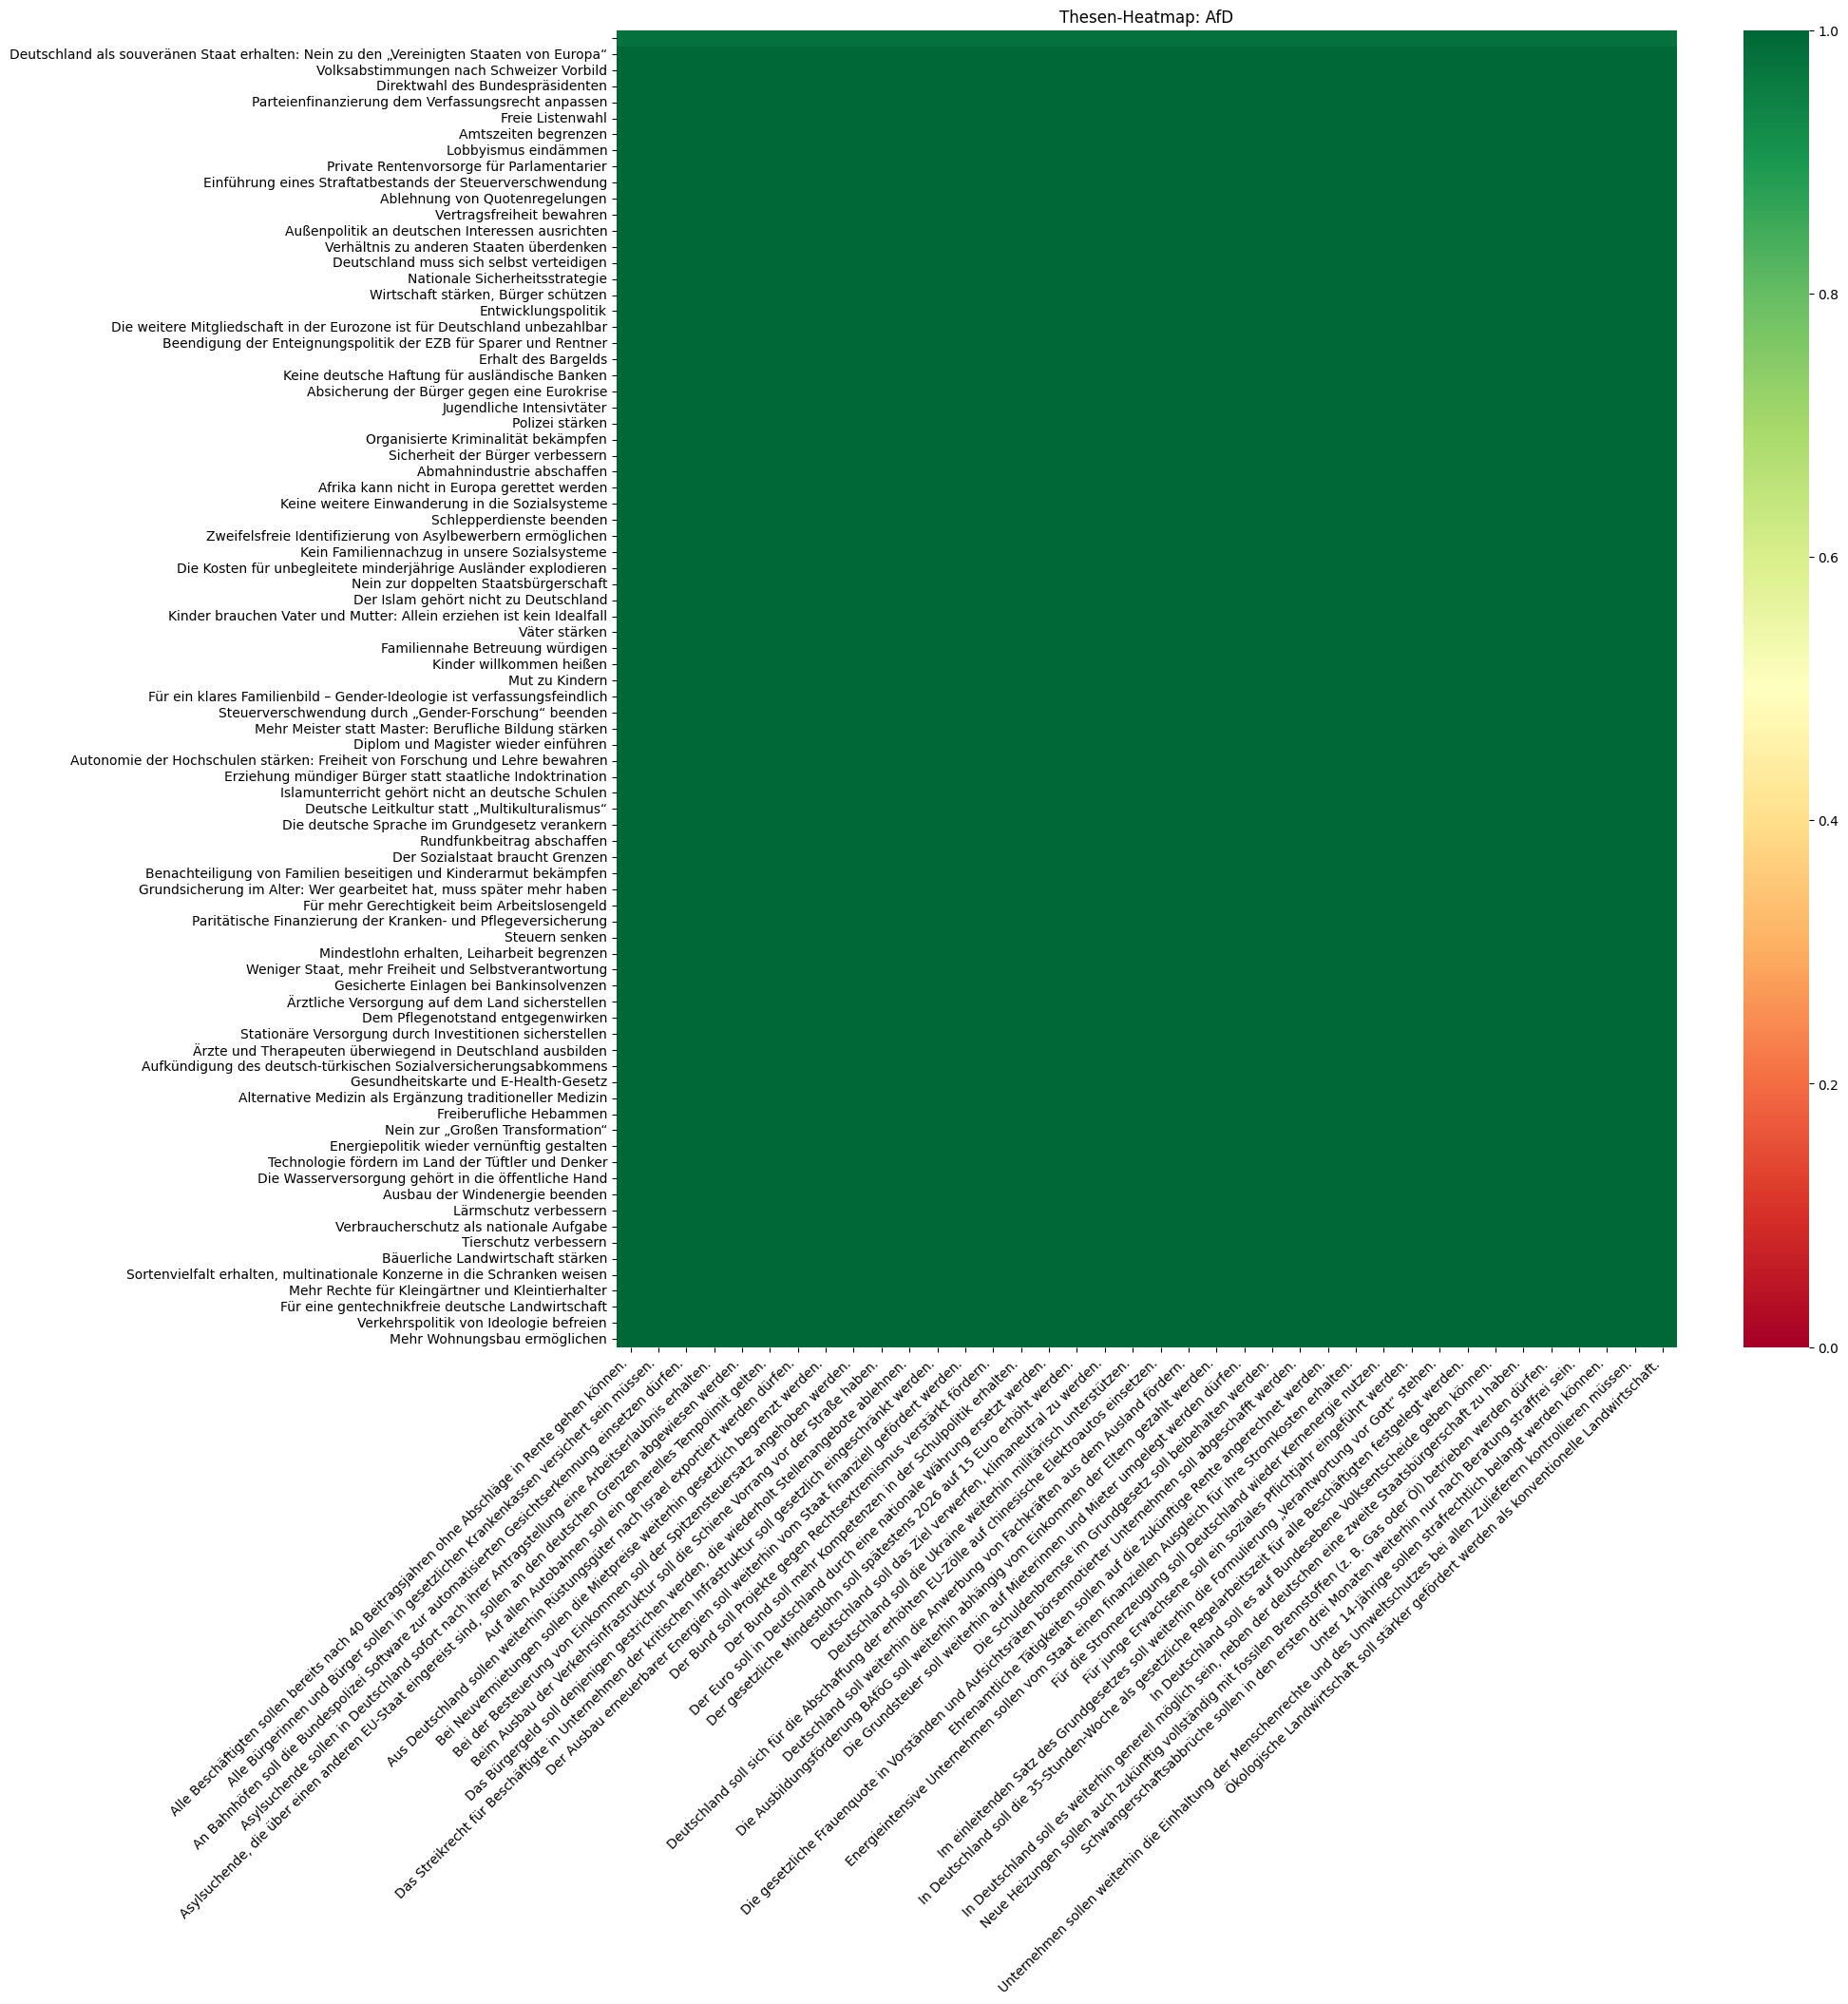

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


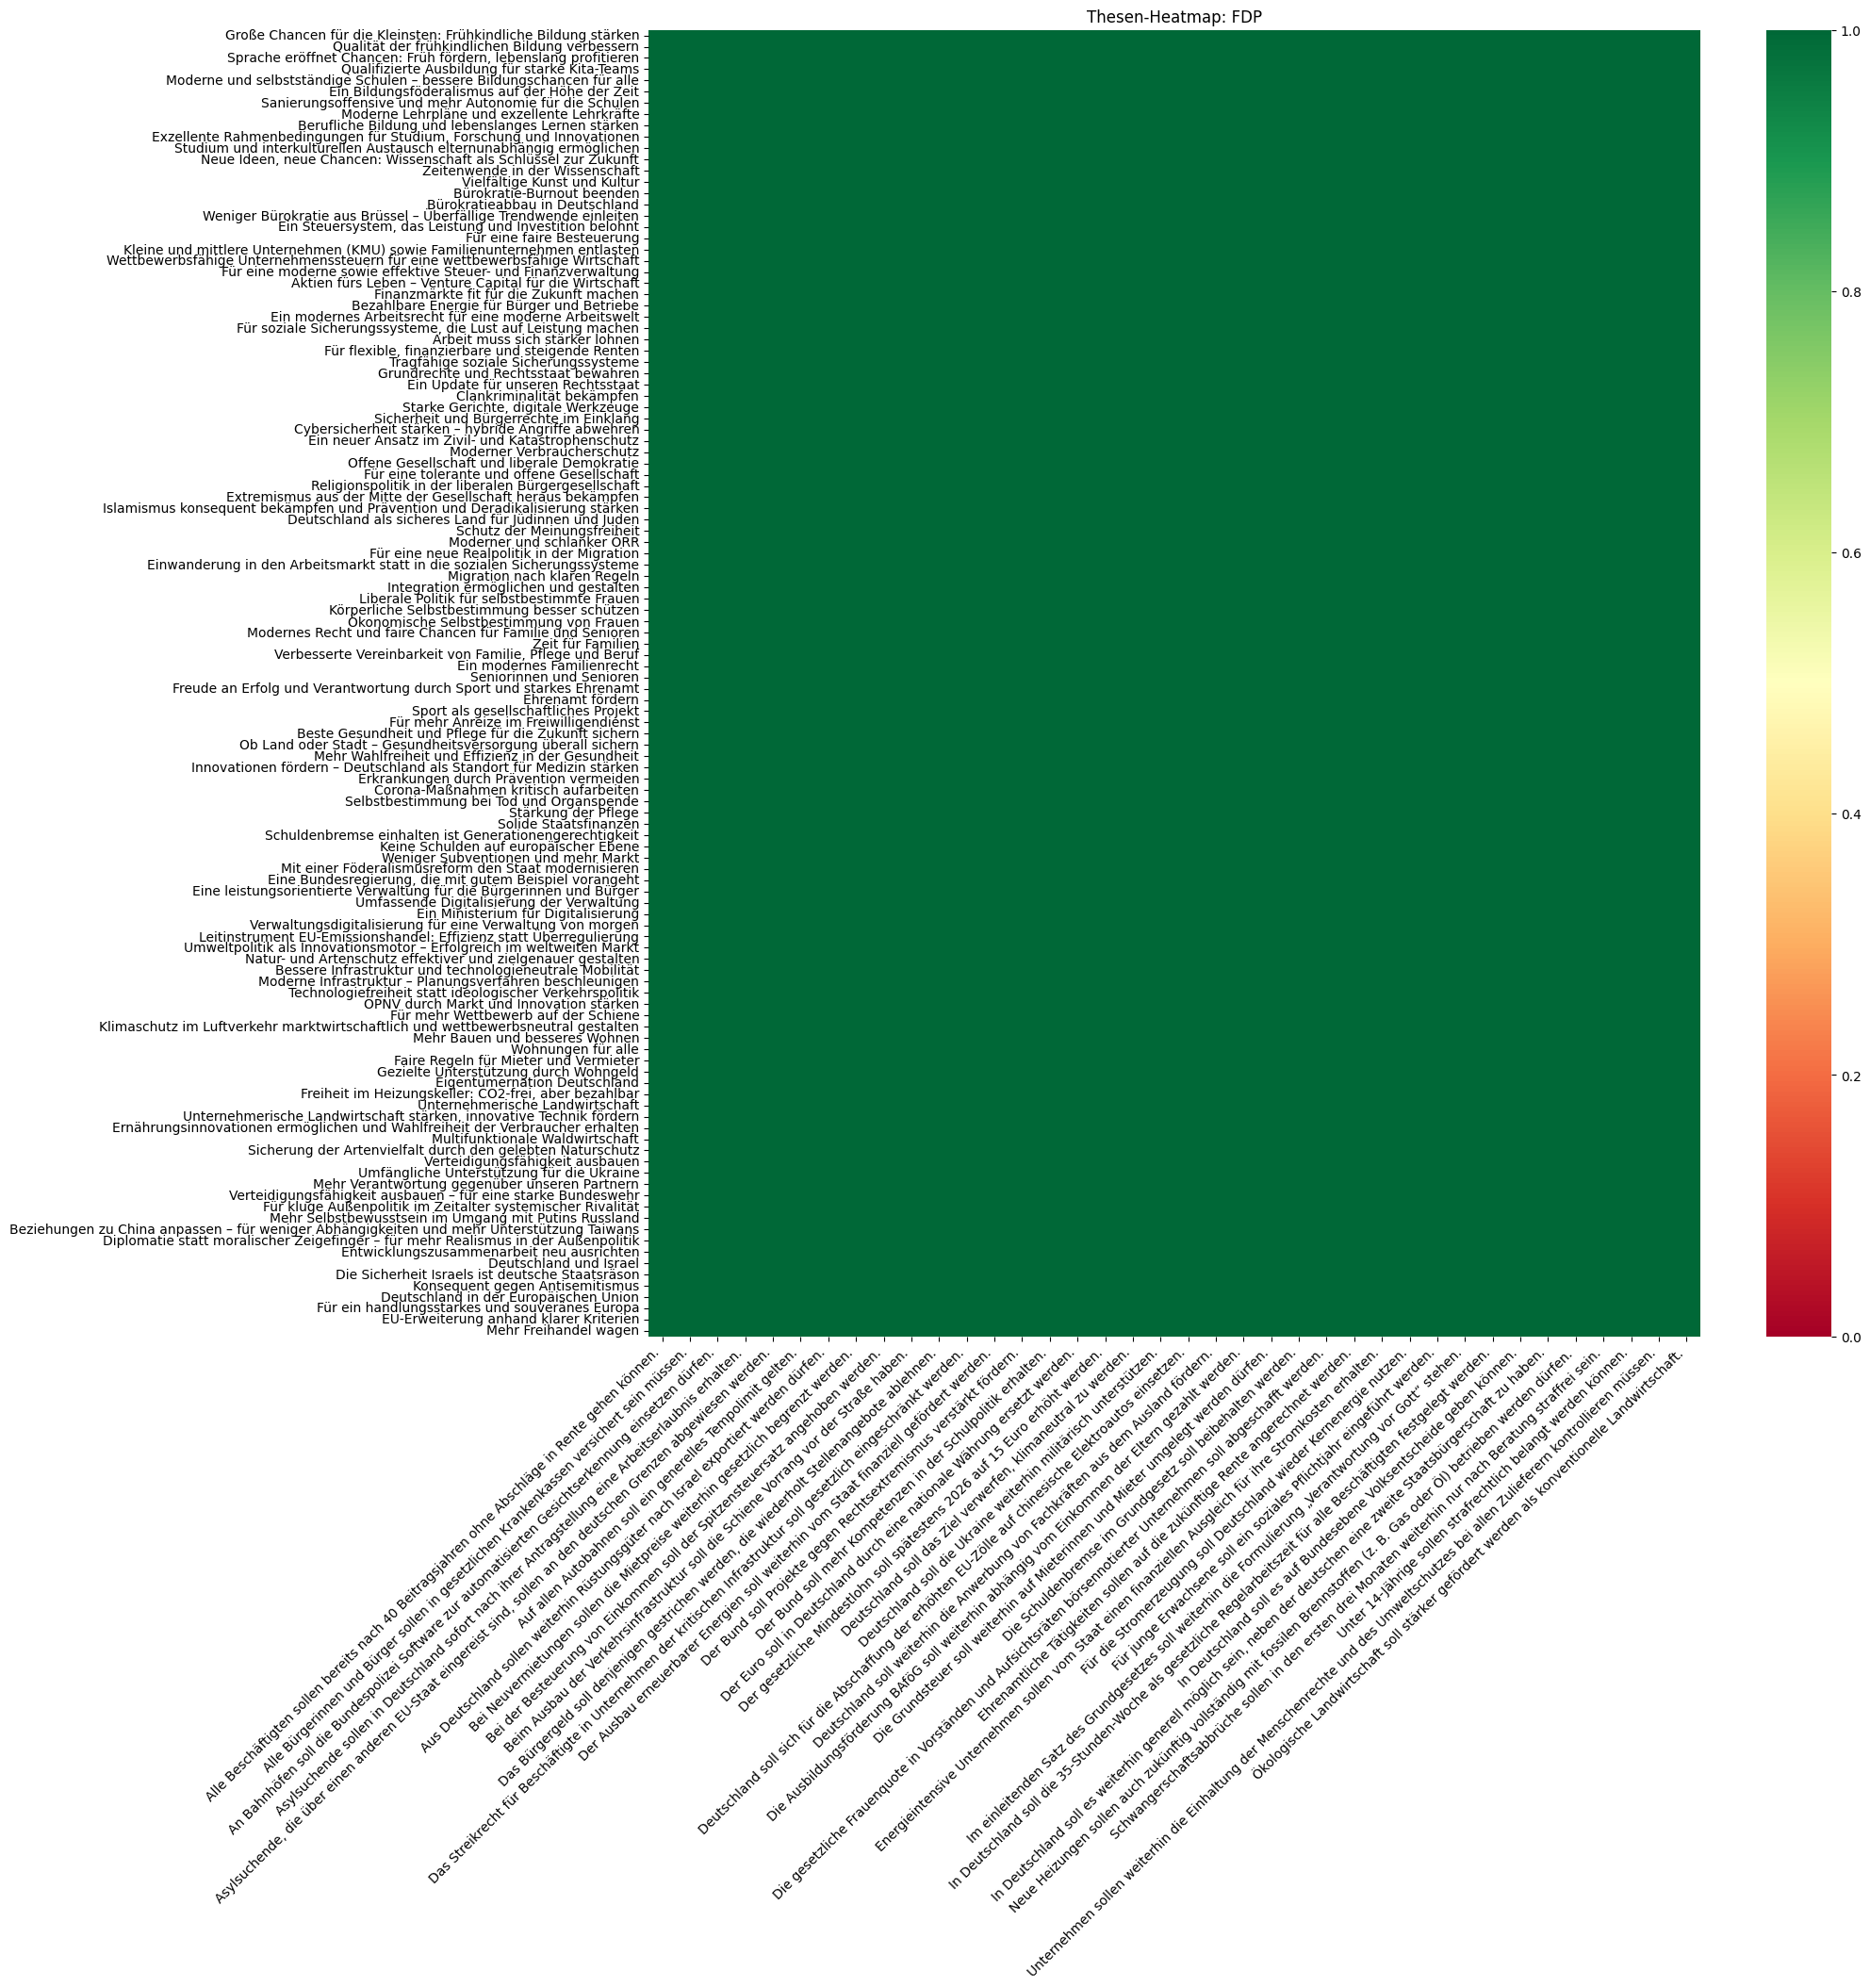

C:\Users\Franziska Rudolf\AppData\Local\Temp\ipykernel_14568\1410588812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


KeyboardInterrupt: 

In [20]:
# Lade das DeBERTa-Modell und den Tokenizer
model_name = "microsoft/deberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Funktion zur Berechnung der Embeddings mit DeBERTa
def get_embedding(text):
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # Verwende den CLS-Token als Repräsentation

# Liste der Parteien und Thesen
parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These'].tolist()
predicted_theses_df = pd.DataFrame()

# Schleife über die Parteien
for party_str in parties_list:
    # Filtern der Daten für die aktuelle Partei
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    
    # Entfernen von Zeilen mit NaN-Werten
    party_df.dropna(inplace=True)
    
    # Extrahieren der Thesen für die aktuelle Partei
    party_these_list = party_df['These'].to_list()

    # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
    similarity_df = pd.DataFrame(columns=['party_these'] + Labled_theses_list)

    # Berechnung der Ähnlichkeit für jede Partei-These
    for party_these in party_these_list:
        party_these_embedding = get_embedding(party_these)
        row = [party_these]

        # Berechnung der Kosinusähnlichkeit für jede labelte These
        for label_these in Labled_theses_list:
            label_these_embedding = get_embedding(label_these)
            similarity_score = cosine_similarity([party_these_embedding], [label_these_embedding])[0][0]
            row.append(similarity_score)

        similarity_df.loc[len(similarity_df)] = row

    # Visualisierung der Ähnlichkeiten als Heatmap
    plt.figure(figsize=(18, 18))
    sns.heatmap(similarity_df[Labled_theses_list],
                cmap='RdYlGn',
                annot=False,
                vmax=1,
                vmin=0,
                yticklabels=similarity_df["party_these"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    # Durchschnittliche Ähnlichkeit für jede Partei
    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].mean().tolist()

# Ausgabe der ersten Zeilen des DataFrames mit den Vorhersagen
print(predicted_theses_df.head())


Old Shit

In [22]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Laden des DeBERTa-Modells für Embeddings
model_name = "microsoft/deberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Funktion zur Umwandlung von Texten in DeBERTa-Embeddings
def get_embedding(text):
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # CLS-Token als Repräsentation

# Laden der Parquet-Dateien
all_textes_df = pd.read_parquet("all_parties_text_combined.parquet")  # Entspricht all_textes_df
df_pivoted = pd.read_parquet("wahlomaten_thesen_positionen.parquet")  # Entspricht df_pivoted

# Embeddings für alle Thesen berechnen
df_pivoted['Embedding'] = df_pivoted['These'].apply(get_embedding)

# Embeddings für alle Partei-Texte berechnen
all_textes_df['Embedding'] = all_textes_df['Text'].apply(get_embedding)

# DataFrame zur Speicherung der Ähnlichkeiten
results = []

# Ähnlichkeit für jede These mit allen Partei-Texten berechnen
for _, these_row in df_pivoted.iterrows():
    these_embedding = these_row['Embedding']
    
    for _, text_row in all_textes_df.iterrows():
        text_embedding = text_row['Embedding']
        similarity = cosine_similarity([these_embedding], [text_embedding])[0][0]
        
        results.append([these_row['These'], text_row['Party'], text_row['Text'], similarity])

# Ergebnisse in DataFrame speichern
df_results = pd.DataFrame(results, columns=['These', 'Partei', 'Passender Text', 'Ähnlichkeit'])

# Pivot-Tabelle erstellen, um Parteien als Spalten zu haben
df_pivot = df_results.pivot(index='These', columns='Partei', values='Ähnlichkeit')

# Speichern als CSV
df_pivot.to_csv("deberta_thesen_parteien.csv", encoding="utf-8")

# Ausgabe der ersten Zeilen
print(df_pivot.head())


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


ValueError: Index contains duplicate entries, cannot reshape